## FC Barcelona VS Real Madrid FC - lats 4 match analysis

# Match Analysis report May 2025 - May 2026

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

FCB_COLOR = '#A50044'
RMA_COLOR = '#00529F'
BG_COLOR = '#F9F9F9'

In [ ]:
matches = pd.read_csv('./data/matches.csv')

matches['date'] = pd.to_datetime(matches['date'])
matches

,match_id,date,competition,home_team,away_team,home_score,away_score,winner
0,1,2026-05-10,LaLiga 2025-26,Barcelona,Real Madrid,2,0,Barcelona
1,2,2026-01-12,Spanish Supercopa Final 2025-26,Barcelona,Real Madrid,3,2,Barcelona
2,3,2025-10-26,LaLiga 2025-26,Real Madrid,Barcelona,2,1,Real Madrid
3,4,2025-05-11,LaLiga 2024-25,Barcelona,Real Madrid,4,3,Barcelona


In [ ]:
def get_goal(row):
  """ Derived Goal column from match table """
  m = matches[matches['match_id'] == row['match_id']].iloc[0]
  if row['team'] == m['home_team']:
    return m['home_score'], m['away_score']
  else:
    return m['away_score'], m['home_score']

stats = pd.read_csv('./data/team_stats.csv')
#stats

stats[['goals_scored', 'goals_conceded']] = stats.apply(
    lambda r: pd.Series(get_goal(r)), axis=1
)

# stats
print("✅✅✅✅✅✅")
print(f"\nMatches: {len(matches)} | Stat rows: {len(stats)}")
print("="*30 + 'MATCH'+'='*30)
print(matches)
print("="*30 + 'STATS'+'='*30)
print(stats)

✅✅✅✅✅✅

Matches: 4 | Stat rows: 8
==============================MATCH==============================
   match_id       date                      competition    home_team  \
0         1 2026-05-10                   LaLiga 2025-26    Barcelona   
1         2 2026-01-12  Spanish Supercopa Final 2025-26    Barcelona   
2         3 2025-10-26                   LaLiga 2025-26  Real Madrid   
3         4 2025-05-11                   LaLiga 2024-25    Barcelona   

     away_team  home_score  away_score       winner  
0  Real Madrid           2           0    Barcelona  
1  Real Madrid           3           2    Barcelona  
2    Barcelona           2           1  Real Madrid  
3  Real Madrid           4           3    Barcelona  
==============================STATS==============================
   match_id         team  possession_pct  shots_on_goal  shot_attempts  fouls  \
0         1    Barcelona            56.7              7             10   18.0   
1         1  Real Madrid            43.3 

In [52]:
print(stats.columns)
print("+"*30)
print(matches.columns)
print("+"*30)
print(stats.info())
print("+"*30)
print(matches.info())
print("+"*30)

Index(['match_id', 'team', 'possession_pct', 'shots_on_goal', 'shot_attempts',
       'fouls', 'yellow_cards', 'red_cards', 'corner_kicks', 'saves',
       'goals_scored', 'goals_conceded'],
      dtype='object')
++++++++++++++++++++++++++++++
Index(['match_id', 'date', 'competition', 'home_team', 'away_team',
       'home_score', 'away_score', 'winner'],
      dtype='object')
++++++++++++++++++++++++++++++
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   match_id        8 non-null      int64  
 1   team            8 non-null      object 
 2   possession_pct  8 non-null      float64
 3   shots_on_goal   8 non-null      int64  
 4   shot_attempts   8 non-null      int64  
 5   fouls           2 non-null      float64
 6   yellow_cards    8 non-null      int64  
 7   red_cards       8 non-null      int64  
 8   corner_kicks    8 non-null      i

## H2H Summary (last 4)

In [53]:
fcb_wins = (matches['winner'] == 'Barcelona').sum()
rma_wins = (matches['winner'] == 'Real Madrid').sum()
# print(fcb_wins, rma_wins)
draws = len(matches) - fcb_wins - rma_wins
total_goals = matches['home_score'].sum() + matches['away_score'].sum()

fcb_goals = stats[stats['team'] == 'Barcelona']['goals_scored'].sum()
rma_goals = stats[stats['team'] == 'Real Madrid']['goals_scored'].sum()

print("+"*48)
print("     FC BARCELONA  vs  REAL MADRID FC")
print("     Last 4 Clásicos  |  2025-2026")
print("+"*48)
print(f"  Matches played:   4")
print(f"  FCB wins:         {fcb_wins}")
print(f"  RMA wins:         {rma_wins}")
print(f"  Draws:            {draws}")
print(f"  Total Goals:      {total_goals}")
print(f"  Goals Scored by FCB: {fcb_goals}")
print(f"  Goals Scored by RMA: {rma_goals}")
print("+"*48)

++++++++++++++++++++++++++++++++++++++++++++++++
     FC BARCELONA  vs  REAL MADRID FC
     Last 4 Clásicos  |  2025-2026
++++++++++++++++++++++++++++++++++++++++++++++++
  Matches played:   4
  FCB wins:         3
  RMA wins:         1
  Draws:            0
  Total Goals:      17
  Goals Scored by FCB: 10
  Goals Scored by RMA: 7
++++++++++++++++++++++++++++++++++++++++++++++++


#Plot 1 - Goals Scored per match


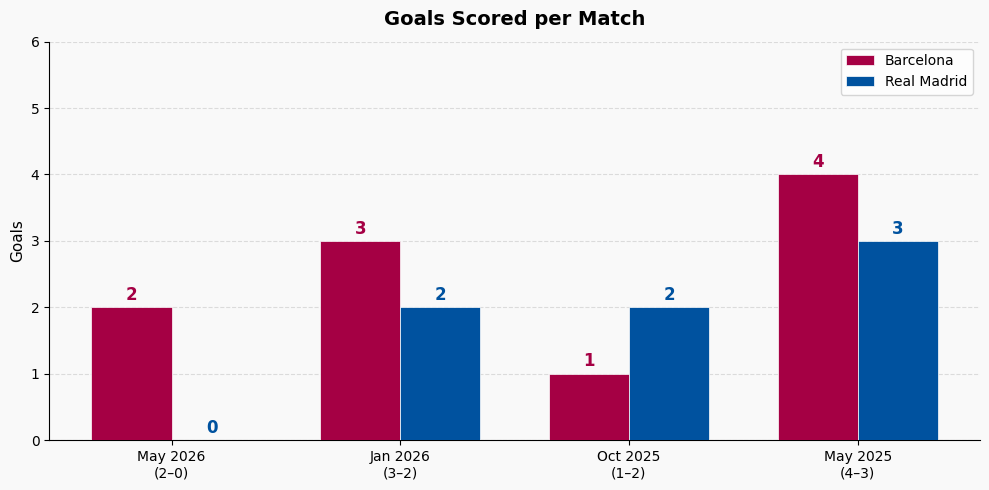

Chart saved: goals_per_match.png


In [54]:
label_map = {4:'May 2025\n(4–3)', 3:'Oct 2025\n(1–2)', 2:'Jan 2026\n(3–2)', 1:'May 2026\n(2–0)'}

fcb_goals_pm = stats[stats['team']=='Barcelona'].set_index('match_id')['goals_scored']
rma_goals_pm = stats[stats['team']=='Real Madrid'].set_index('match_id')['goals_scored']

x = np.arange(4)
w =0.35
labels = [label_map[i] for i in [1, 2, 3, 4]]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars1 = ax.bar(x-w/2, [fcb_goals_pm[i] for i in [1, 2, 3, 4]], w, label='Barcelona',
        color=FCB_COLOR, zorder=3, edgecolor='white', linewidth=0.5)

bars2 = ax.bar(x+w/2, [rma_goals_pm[i] for i in [1, 2, 3, 4]], w, label='Real Madrid',
        color=RMA_COLOR, zorder=3, edgecolor='white', linewidth=0.5)

for bar in bars1:
  ax.text(
      bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
      int(bar.get_height()), ha='center', va='bottom',
      fontsize=12, fontweight='bold', color=FCB_COLOR
  )

for bar in bars2:
  ax.text(
      bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
      int(bar.get_height()), ha='center', va='bottom',
      fontsize=12, fontweight='bold', color=RMA_COLOR
  )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Goals', fontsize=11)
ax.set_title('Goals Scored per Match', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 6)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('goals_per_match.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: goals_per_match.png")

#Plot 2 - Possession(%) per match

In [55]:
fcb_poss = stats[stats['team']=='Barcelona'].set_index('match_id')['possession_pct']
rma_poss=stats[stats['team']=='Real Madrid'].set_index('match_id')['possession_pct']

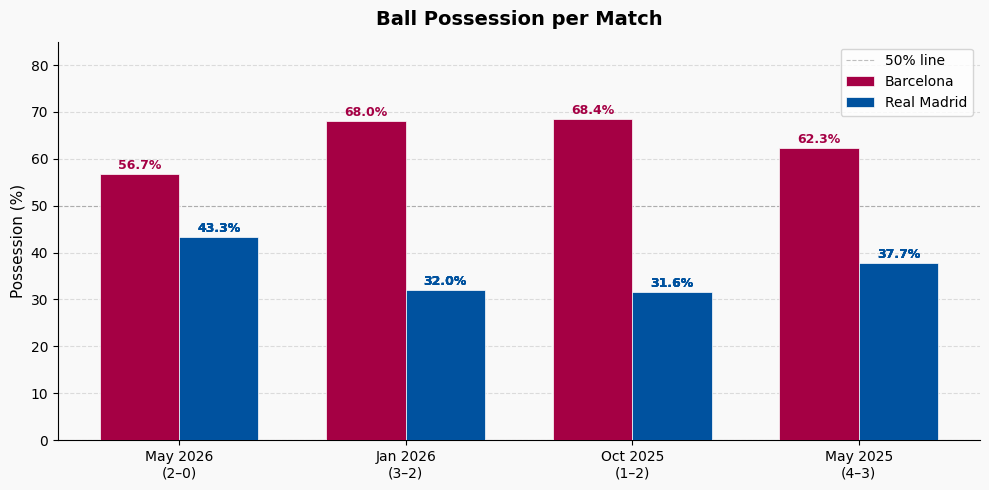

Chart saved: possession_per_match.png


In [56]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars1 = ax.bar(x-w/2, [fcb_poss[i] for i in [1, 2, 3, 4]], w,
               label='Barcelona', color=FCB_COLOR, zorder=3, edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x+w/2, [rma_poss[i] for i in [1, 2, 3, 4]], w,
               label='Real Madrid', color=RMA_COLOR, zorder=3, edgecolor='white', linewidth=0.5)

for bar in bars1:
  ax.text(
      bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
      f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9,
      color=FCB_COLOR, fontweight='bold'
  )

  for bar in bars2:
    ax.text(
      bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
      f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9,
      color=RMA_COLOR, fontweight='bold'
  )



ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='50% line')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Possession (%)', fontsize=11)
ax.set_title('Ball Possession per Match', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 85)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('possession_per_match.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: possession_per_match.png")

# Plot 3 — Stacked Possession Bar

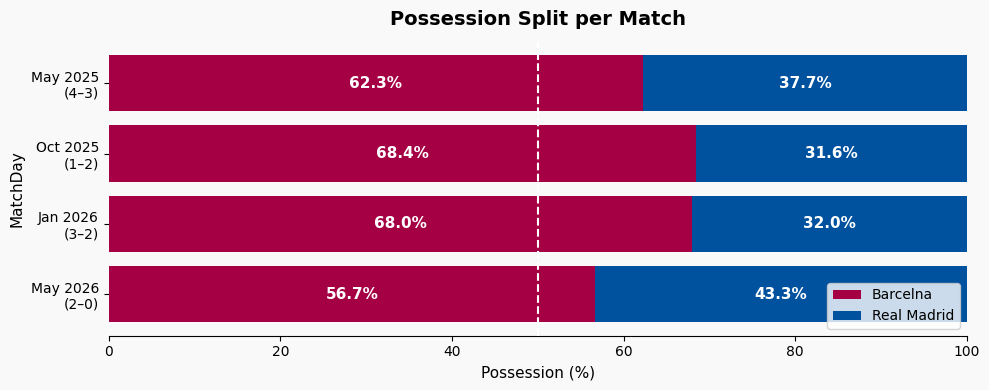

Chart saved: possession_stacked.png


In [57]:
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

fcb_p = [fcb_poss[i] for i in [1,2,3,4]]
rma_p = [rma_poss[i] for i in [1,2, 3,4]]

ax.barh(x, fcb_p, color=FCB_COLOR, label='Barcelna', zorder=3)
ax.barh(x, rma_p, left=fcb_p, color=RMA_COLOR, label='Real Madrid', zorder=3)

for i, (fp, rp) in enumerate(zip(fcb_p, rma_p)):
  ax.text(fp/2, i, f'{fp}%', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
  ax.text(fp+ rp/2, i, f'{rp}%', ha='center', va='center', color='white', fontsize=11, fontweight='bold')


ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, 100)
ax.set_xlabel('Possession (%)', fontsize=11)
ax.set_ylabel('MatchDay', fontsize=11)
ax.set_title('Possession Split per Match', fontsize=14, fontweight='bold', pad=12)
ax.axvline(50, color='white', linewidth=1.5, linestyle='--', zorder=4)
ax.legend(fontsize=10, loc='lower right')
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('possession_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: possession_stacked.png")

# Plot 4 - Shots on Goal vs Shot Attempts

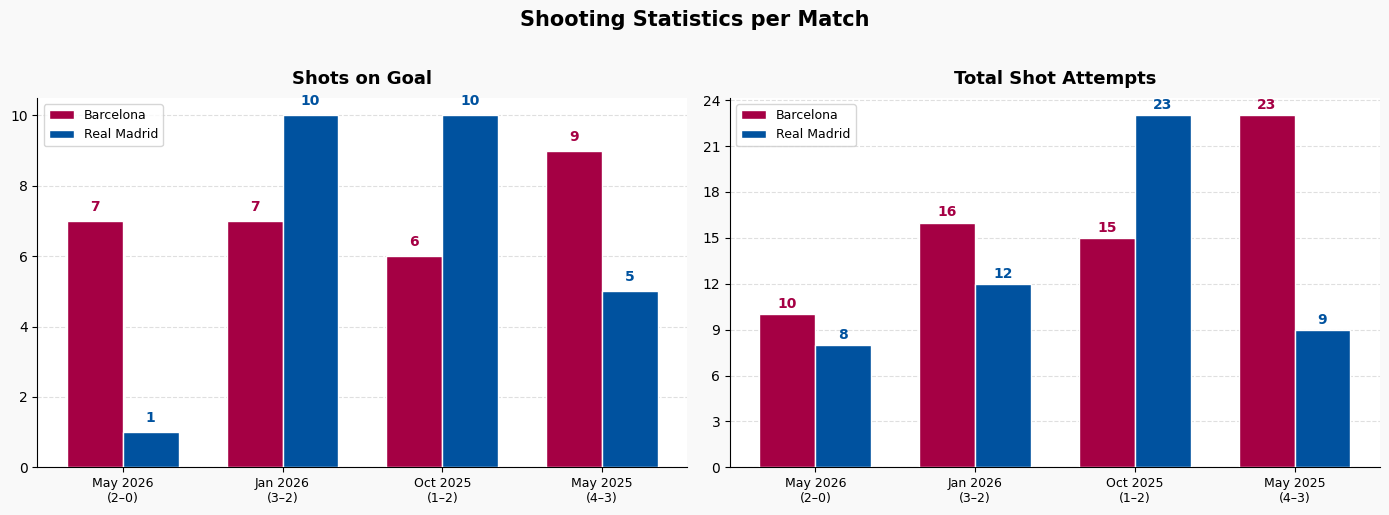

Chart saved: shots_per_match.png


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG_COLOR)

for ax, col, title in zip(
    axes,
    ['shots_on_goal', 'shot_attempts'],
    ['Shots on Goal', 'Total Shot Attempts']
):
  fcb_v=stats[stats['team'] == 'Barcelona'].set_index('match_id')[col]
  rma_v=stats[stats['team'] == 'Real Madrid'].set_index('match_id')[col]

  b1 = ax.bar(x-w/2, [fcb_v[i] for i in [1,2,3,4]], w,
              label='Barcelona', color=FCB_COLOR, zorder=3, edgecolor='white')
  b2 = ax.bar(x+w/2, [rma_v[i] for i in [1,2,3,4]], w,
              label='Real Madrid', color=RMA_COLOR, zorder=3, edgecolor='white')

  for i in b1:
    ax.text(i.get_x()+i.get_width()/2, i.get_height()+0.2,
            int(i.get_height()), ha='center', va='bottom', fontsize=10, fontweight='bold', color=FCB_COLOR)

  for j in b2:
    ax.text(j.get_x()+j.get_width()/2, j.get_height()+0.2,
            int(j.get_height()), ha='center', va='bottom', fontsize=10, fontweight='bold', color=RMA_COLOR)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle('Shooting Statistics per Match', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shots_per_match.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: shots_per_match.png")

# Plot 5 - Overall Average Stats

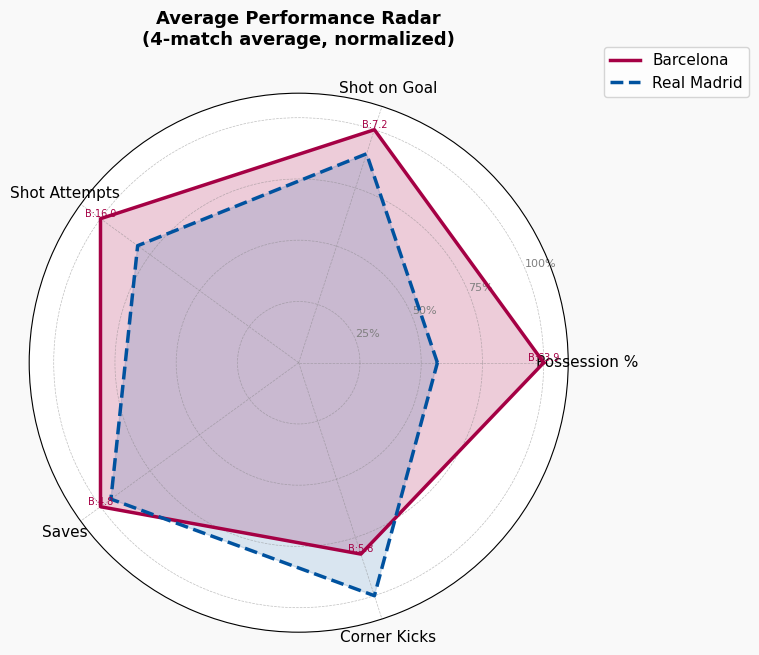

Chart saved: radar_chart.png


In [59]:
from matplotlib.patches import FancyArrowPatch

categories = ['Possession %', 'Shot on Goal', 'Shot Attempts', 'Saves', 'Corner Kicks']
N=len(categories)

fcb_avg = [
    stats[stats['team'] == 'Barcelona']['possession_pct'].mean(),
    stats[stats['team'] == 'Barcelona']['shots_on_goal'].mean(),
    stats[stats['team'] == 'Barcelona']['shot_attempts'].mean(),
    stats[stats['team'] == 'Barcelona']['saves'].mean(),
    stats[stats['team'] == 'Barcelona']['corner_kicks'].mean()
]

rma_avg = [
    stats[stats['team'] == 'Real Madrid']['possession_pct'].mean(),
    stats[stats['team'] == 'Real Madrid']['shots_on_goal'].mean(),
    stats[stats['team'] == 'Real Madrid']['shot_attempts'].mean(),
    stats[stats['team'] == 'Real Madrid']['saves'].mean(),
    stats[stats['team'] == 'Real Madrid']['corner_kicks'].mean()
]

# Normalize
all_vals=np.array([fcb_avg, rma_avg])
max_val=all_vals.max(axis=0)
fcb_norm = fcb_avg/max_val
rma_norm = rma_avg/max_val

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
fcb_norm = np.append(fcb_norm, fcb_norm[0])
rma_norm = np.append(rma_norm, rma_norm[0])
angles+=[angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True), facecolor=BG_COLOR)

ax.plot(angles, fcb_norm, color=FCB_COLOR, linewidth=2.5, label='Barcelona')
ax.fill(angles, fcb_norm, color=FCB_COLOR, alpha=0.2)
ax.plot(angles, rma_norm, color=RMA_COLOR, linewidth=2.5, label='Real Madrid', linestyle='--')
ax.fill(angles, rma_norm, color=RMA_COLOR, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
ax.set_title('Average Performance Radar\n(4-match average, normalized)\n', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

for i, (fc, rc, angle) in enumerate(zip(fcb_avg, rma_avg, angles[:-1])):
    ax.annotate(f'B:{fc:.1f}', xy=(angle, fcb_norm[i]), fontsize=7, color=FCB_COLOR,
                ha='center', va='bottom')

plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: radar_chart.png")

# Aggregated Stats Table

In [60]:
summary = stats.groupby('team').agg(
    total_goals=('goals_scored', 'sum'),
    avg_possession=('possession_pct', 'mean'),
    total_shots_on_goal=('shots_on_goal', 'sum'),
    total_shot_attempts=('shot_attempts', 'sum'),
    total_corner_kicks=('corner_kicks', 'sum'),
  total_saves=('saves', 'sum')
)

summary
print("="*114)
print(summary.to_string())
print("="*114)

for team in ['Barcelona', 'Real Madrid']:
    t = stats[stats['team']==team]
    acc = (t['shots_on_goal'].sum() / t['shot_attempts'].sum()) * 100
    print(f"{team} shot accuracy: {acc:.1f}%")

             total_goals  avg_possession  total_shots_on_goal  total_shot_attempts  total_corner_kicks  total_saves
team                                                                                                               
Barcelona             10           63.85                   29                   64                  23           19
Real Madrid            7           36.15                   26                   52                  28           18
Barcelona shot accuracy: 45.3%
Real Madrid shot accuracy: 50.0%


<center>Data source: ESPN</center>